In [1]:
import numpy as np
import pandas as pd

In [2]:
lambda05 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_0.5_results.tsv", sep="\t")
lambda05["lambda"] = [0.5 for i in range(len(lambda05))]

In [3]:
lambda10 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.0_results.tsv", sep="\t")
lambda10["lambda"] = [1.0 for i in range(len(lambda10))]

In [4]:
lambda11 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.1_results.tsv", sep="\t")
lambda11["lambda"] = [1.1 for i in range(len(lambda11))]

In [5]:
lambda12 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.2_results.tsv", sep="\t")
lambda12["lambda"] = [1.2 for i in range(len(lambda12))]

In [6]:
lambda13 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.3_results.tsv", sep="\t")
lambda13["lambda"] = [1.3 for i in range(len(lambda13))]

In [7]:
lambda14 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.4_results.tsv", sep="\t")
lambda14["lambda"] = [1.4 for i in range(len(lambda14))]

In [8]:
lambda15 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.5_results.tsv", sep="\t")
lambda15["lambda"] = [1.5 for i in range(len(lambda15))]

In [9]:
lambda16 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.6_results.tsv", sep="\t")
lambda16["lambda"] = [1.6 for i in range(len(lambda16))]

In [10]:
lambda17 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.7_results.tsv", sep="\t")
lambda17["lambda"] = [1.7 for i in range(len(lambda17))]

In [11]:
lambda18 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.8_results.tsv", sep="\t")
lambda18["lambda"] = [1.8 for i in range(len(lambda18))]

In [13]:
lambda19 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_1.9_results.tsv", sep="\t")
lambda19["lambda"] = [1.9 for i in range(len(lambda19))]

In [12]:
lambda20 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_2.0_results.tsv", sep="\t")
lambda20["lambda"] = [2.0 for i in range(len(lambda20))]

In [14]:
lambda25 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_2.5_results.tsv", sep="\t")
lambda25["lambda"] = [2.5 for i in range(len(lambda25))]

In [15]:
lambda50 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lambda_5.0_results.tsv", sep="\t")
lambda50["lambda"] = [5.0 for i in range(len(lambda50))]

In [16]:
df = pd.concat([lambda05, lambda10, 
                lambda11, lambda12, lambda13, lambda14, lambda15,
                lambda16, lambda17, lambda18, lambda19, lambda20, 
                lambda25, lambda50], ignore_index=True)

In [17]:
df = df[df["SCD"] > 20.0]

In [18]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

/tmp/SLURM_1129579/ipykernel_1794704/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1129579/ipykernel_1794704/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1129579/ipykernel_1794704/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1129579/ipyker

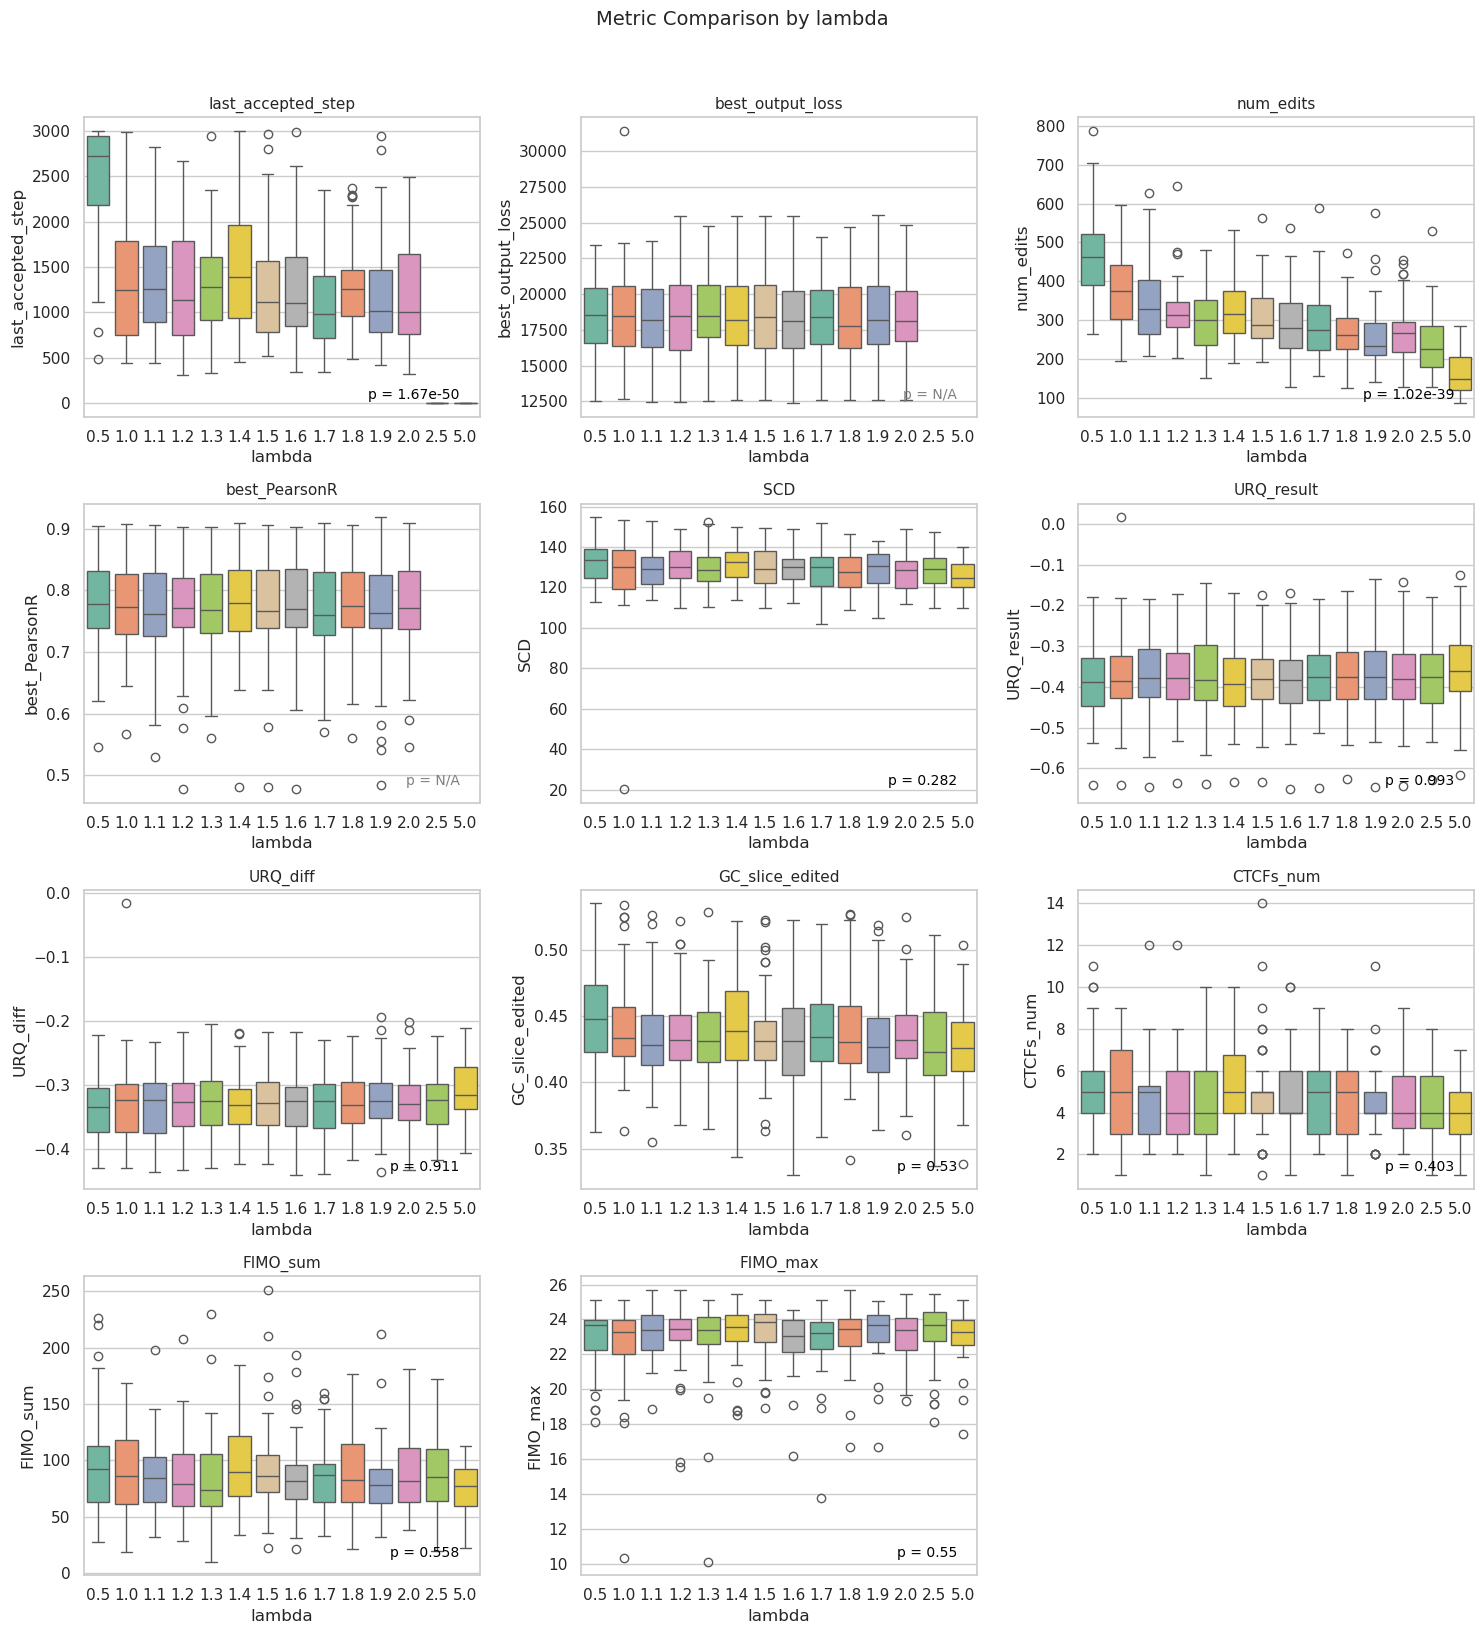

In [20]:
# Define metrics and tau order
metrics = [
    'last_accepted_step', 'best_output_loss', 'num_edits', 'best_PearsonR',
    'SCD', 'URQ_result', 'URQ_diff', 'GC_slice_edited',
    'CTCFs_num', 'FIMO_sum', 'FIMO_max'
]

# Optional: make sure tau is float
df['lambda'] = df['lambda'].astype(float)

# Sort tau values for consistent order in plots
lambda_order = sorted(df['lambda'].unique())

# Set up grid
n_cols = 3
n_rows = -(-len(metrics) // n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("lambda")
    ax.set_ylabel(metric)

    # Kruskal-Wallis test across all tau groups
    try:
        groups = [df[df['lambda'] == l][metric].dropna() for l in lambda_order]
        if all(len(g) > 0 for g in groups):
            stat, pval = kruskal(*groups)
            ax.text(0.95, 0.05, f"p = {pval:.3g}", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='black')
        else:
            ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='gray')
    except ValueError:
        ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='gray')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Metric Comparison by lambda", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
avg_edits_per_lambda = df.groupby('lambda')['num_edits'].mean().reset_index()
print(avg_edits_per_lambda)

    lambda   num_edits
0      0.5  463.782609
1      1.0  380.600000
2      1.1  337.568182
3      1.2  323.227273
4      1.3  302.044444
5      1.4  327.456522
6      1.5  307.217391
7      1.6  289.533333
8      1.7  291.204545
9      1.8  271.023256
10     1.9  257.977273
11     2.0  271.285714
12     2.5  239.500000
13     5.0  158.447368
